In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans as kmeans

In [2]:

# THE MATH BEHIND K-MEANS


# Goal: Group data into K clusters without labels (unsupervised).

# Algorithm:
#   1. Randomly place K centroids
#   2. Assign each point to the nearest centroid
#   3. Move each centroid to the mean of its assigned points
#   4. Repeat steps 2-3 until centroids stop moving
#
# Cost (Inertia):
#   J = sum over all points: distance(point, its_centroid)^2

# This is called the Expectation-Maximization (EM) pattern:
#   E-step: assign points to clusters (expectation)
#   M-step: update centroids (maximization)


print("K-Means summary:")
print("  1. Initialize K random centroids")
print("  2. Assign each point to nearest centroid")
print("  3. Update centroids to cluster means")
print("  4. Repeat until convergence")

K-Means summary:
  1. Initialize K random centroids
  2. Assign each point to nearest centroid
  3. Update centroids to cluster means
  4. Repeat until convergence


In [11]:
class KMeansScratch:

    def __init__(self,  n_clusters=3, max_iteration=500, random_state=42):
        self.k = n_clusters
        self.max_iter = max_iteration
        self.r = random_state
        self.centroids = None
        self.labels = None
        self.inertia_history = []

    def _euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1 - x2) ** 2, axis=-1))

    def fit(self, X):
        np.random.seed(self.r)
        n_samples = X.shape[0]

        random_idx = np.random.choice(n_samples, self.k, replace=False)
        self.centroids = X[random_idx].copy()
        self.inertia_history = []

        for iteration in range(self.max_iter):
            distances = np.array([self._euclidean_distance(X, c) for c in self.centroids])
            self.labels = np.argmin(distances, axis=0)

            inertia = sum(
                np.sum(self._euclidean_distance(X[self.labels == k], self.centroids[k]) ** 2)
                for k in range(self.k) if np.sum(self.labels == k) > 0
            )
            self.inertia_history.append(inertia)

            new_centroids = np.array([
                X[self.labels == k].mean(axis=0) if np.sum(self.labels == k) > 0
                else self.centroids[k]
                for k in range(self.k)
            ])

            if np.allclose(self.centroids, new_centroids):
                print(f"Converged at iteration {iteration + 1}")
                break

            self.centroids = new_centroids
        
        self.inertia = self.inertia_history[-1]
        return self

    def predict(self, X):
        distances = np.array([self._euclidean_distance(X, c) for c in self.centroids])
        return np.argmin

    

    

In [12]:
np.random.seed(42)

X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.0, random_state=42)

model = KMeansScratch(n_clusters=4)

model.fit(X)

Converged at iteration 4


Converged at iteration 4


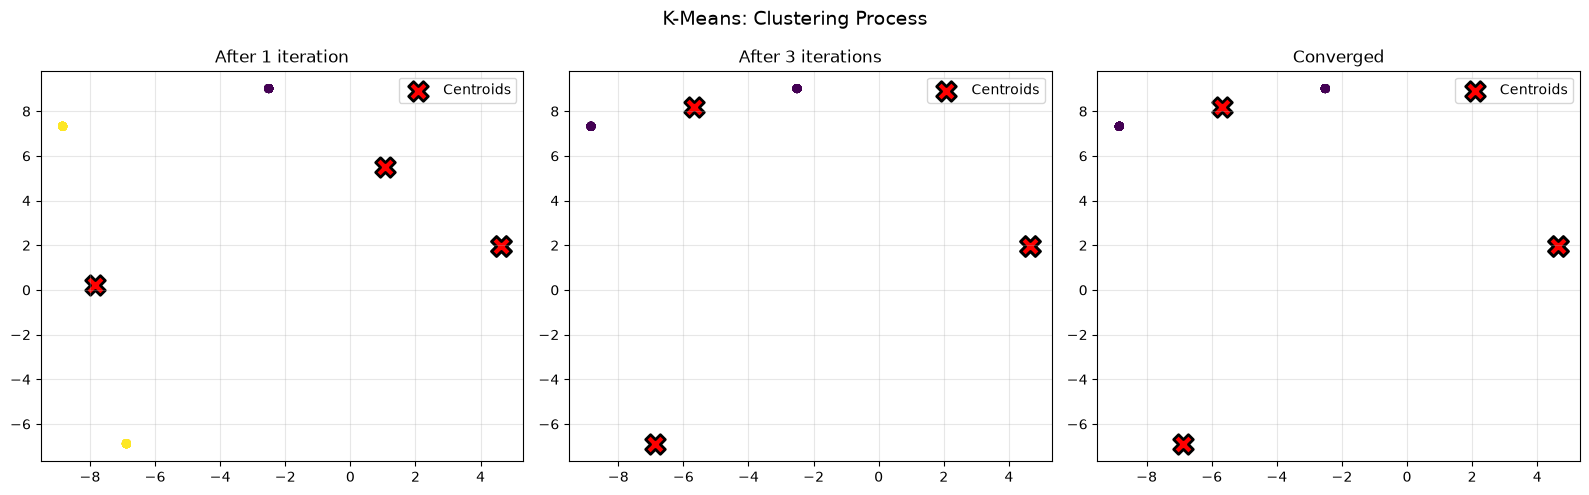

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Step-by-step visualization
for ax, n_iter, title in zip(axes, [1, 3, 50], ['After 1 iteration', 'After 3 iterations', 'Converged']):
    m = KMeansScratch(n_clusters=4, max_iteration=n_iter)
    m.fit(X)
    
    ax.scatter(X[:, 0], X[:, 1], c=m.labels, cmap='viridis', alpha=0.6, s=30)
    ax.scatter(m.centroids[:, 0], m.centroids[:, 1], c='red', marker='X', 
               s=200, edgecolors='black', linewidths=2, label='Centroids')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('K-Means: Clustering Process', fontsize=14)
plt.tight_layout()
plt.savefig('kmeans_results.png', dpi=150, bbox_inches='tight')
plt.show()

Converged at iteration 2
Converged at iteration 2
Converged at iteration 4
Converged at iteration 4
Converged at iteration 3
Converged at iteration 2
Converged at iteration 2
Converged at iteration 3
Converged at iteration 3
Converged at iteration 3


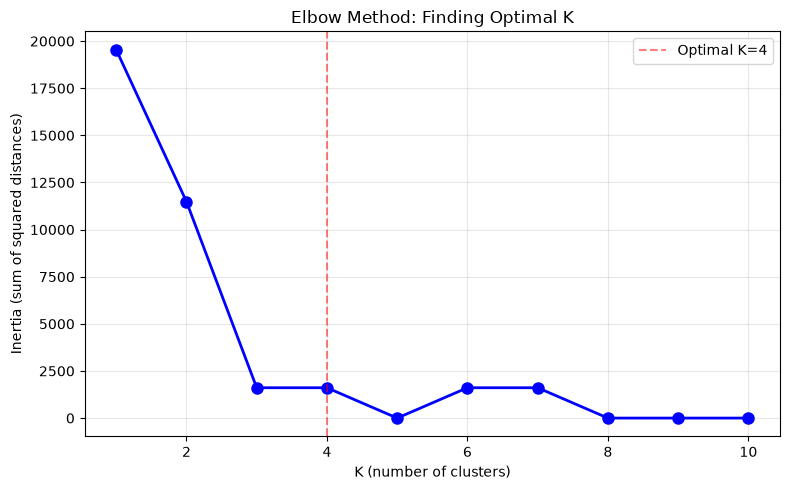

Chart saved!


In [26]:
# Elbow methods: finding the optimal k 

inertias = []
k_range = range(1, 11)

for k in k_range:
    m = KMeansScratch(n_clusters=k)
    m.fit(X)
    inertias.append(m.inertia)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('K (number of clusters)')
plt.ylabel('Inertia (sum of squared distances)')
plt.title('Elbow Method: Finding Optimal K')
plt.axvline(x=4, color='r', linestyle='--', alpha=0.5, label='Optimal K=4')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [28]:
sklearn_model = kmeans(n_clusters=4, random_state=42, n_init=10)
sklearn_model.fit(X)

print(f"{'Metric':<25} {'From Scratch':>15} {'Scikit-Learn':>15}")
print(f"{'-'*55}")
print(f"{'Inertia':<25} {model.inertia:>15.2f} {sklearn_model.inertia_:>15.2f}")
print(f"\nCentroid comparison:")
for i in range(4):
    print(f"  Cluster {i}: Scratch={np.round(model.centroids[i], 2)}, Sklearn={np.round(sklearn_model.cluster_centers_[i], 2)}")

Metric                       From Scratch    Scikit-Learn
-------------------------------------------------------
Inertia                           1609.37            0.00

Centroid comparison:
  Cluster 0: Scratch=[-5.67  8.17], Sklearn=[-2.51  9.01]
  Cluster 1: Scratch=[-6.88 -6.88], Sklearn=[-6.88 -6.88]
  Cluster 2: Scratch=[4.64 1.97], Sklearn=[4.64 1.97]
  Cluster 3: Scratch=[4.64 1.97], Sklearn=[-8.84  7.32]


In [29]:
print("""
============================================================
K-MEANS CLUSTERING FROM SCRATCH — COMPLETE
============================================================

What was built:
  - KMeansScratch class using only NumPy
  - Random centroid initialization
  - Iterative assignment and update (EM pattern)
  - Convergence detection
  - Elbow method for optimal K selection

Key concepts:
  - K-Means is UNSUPERVISED (no labels needed)
  - Algorithm: assign → update centroids → repeat
  - Inertia measures cluster tightness
  - Elbow method finds optimal number of clusters
  - Results depend on initialization (run multiple times)

Verified against scikit-learn: results comparable.

Next: Naive Bayes from scratch
============================================================
""")


K-MEANS CLUSTERING FROM SCRATCH — COMPLETE

What was built:
  - KMeansScratch class using only NumPy
  - Random centroid initialization
  - Iterative assignment and update (EM pattern)
  - Convergence detection
  - Elbow method for optimal K selection

Key concepts:
  - K-Means is UNSUPERVISED (no labels needed)
  - Algorithm: assign → update centroids → repeat
  - Inertia measures cluster tightness
  - Elbow method finds optimal number of clusters
  - Results depend on initialization (run multiple times)

Verified against scikit-learn: results comparable.

Next: Naive Bayes from scratch

